Handle Data

Check the range of input variables

Feature Scaling - Before we feed data to aneural network, it's good idea to check all input variables span similar ranges to avoid problem of model focusing on larger loss feature because of different input variable range.

- Standardizing input variable: resclae the inputs so that their average is 0 and their standard deviation is 1.

Low SD means values tend to stay close to their average. 

Ex: standardized_inputs = (inputs - np.average(inputs)) / np.std(inputs)


## Preparing Data

In [4]:
import numpy as np
import struct

In [5]:
def load_images(filename):
    with open(filename,'rb') as f:
        _ignored,n_images,columns,rows = struct.unpack('>IIII',f.read(16))
        all_pixels = np.frombuffer(f.read(),dtype=np.uint8)
        return all_pixels.reshape(n_images,columns*rows)

def load_labels(filename):
    with open(filename,'rb') as f:
        f.read(8) #skip the header bytes
        all_labels = f.read()
        return np.frombuffer(all_labels,dtype=np.uint8).reshape(-1,1)

def one_hot_encode(Y):
    n_labels = Y.shape[0]
    n_classes = 10
    encoded_Y = np.zeros((n_labels,n_classes))
    for i in range(n_labels):
        label = Y[i]
        encoded_Y[i][label] = 1
    return encoded_Y

In [6]:
Y_train_unencoded = load_labels("Datasets/archive/train-labels-idx1-ubyte/train-labels-idx1-ubyte")

Y_train = one_hot_encode(Y_train_unencoded)

Y_test_all = load_labels("Datasets/archive/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte")

Y_validation,Y_test = np.split(Y_test_all,2)

In [7]:
X_train_non_standardized = load_images("Datasets/archive/train-images-idx3-ubyte/train-images-idx3-ubyte")

X_test_all_non_standardized = load_images("Datasets/archive/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte")

X_validation_non_standardized,X_test_non_standardized = np.split(X_test_all_non_standardized,2)

In [8]:
def standardize(training_set, test_set):
    average = np.average(training_set)
    standard_deviation = np.std(training_set)
    training_set_standardized = (training_set - average) / standard_deviation
    test_set_standardized = (test_set - average) / standard_deviation
    return (training_set_standardized,test_set_standardized)

'''If we ever deployed our network to production, 
we would also have to standardize production data with 
the same average and standard deviation.'''

'If we ever deployed our network to production, \nwe would also have to standardize production data with \nthe same average and standard deviation.'

In [9]:
#standardized X_train and X_validation and X_test

X_train, X_test_all = standardize(X_train_non_standardized,X_test_all_non_standardized)

X_validation, X_test = np.split(X_test_all,2)


## The Neural Network

In [10]:
def sigmoid(z):
    return 1/(1+np.exp(-z))

def softmax(logits):
    exponentials = np.exp(logits)
    return exponentials / np.sum(exponentials,axis=1).reshape(-1,1)

def sigmoid_gradient(sigmoid):
    return np.multiply(sigmoid,(1-sigmoid))

def loss(Y,y_hat):
    return -np.sum(Y*np.log(y_hat)) / Y.shape[0]

def prepend_bias(X):
    return np.insert(X,0,1,axis=1)

def forward(X,w1,w2):
    h = sigmoid(np.matmul(prepend_bias(X),w1))
    y_hat = softmax(np.matmul(prepend_bias(h),w2))
    return (y_hat,h)

def back(X,Y,y_hat,w2,h):
    w2_gradient = np.matmul(prepend_bias(h).T,(y_hat - Y)) / X.shape[0]
    w1_gradient = np.matmul(prepend_bias(X).T, np.matmul(y_hat-Y,w2[1:].T)
                            * sigmoid_gradient(h)) / X.shape[0]
    
    return (w1_gradient,w2_gradient)

def classify(X,w1,w2):
    y_hat,_ = forward(X,w1,w2)
    labels = np.argmax(y_hat,axis=1)
    return labels.reshape(-1,1)

def initialize_weights(n_input_variables, n_hidden_nodes, n_classes):
    w1_rows = n_input_variables + 1
    w1 = np.random.randn(w1_rows,n_hidden_nodes) * np.sqrt(1/w1_rows)

    w2_rows = n_hidden_nodes + 1
    w2 = np.random.randn(w2_rows,n_classes) * np.sqrt(1/w2_rows)

    return (w1,w2)

def prepare_batches(X_train,Y_train,batch_size):
    x_batches = []
    y_batches = []
    n_examples = X_train.shape[0]

    for batch in range(0,n_examples,batch_size):
        batch_end = batch + batch_size
        x_batches.append(X_train[batch:batch_end])
        y_batches.append(Y_train[batch:batch_end])

    return x_batches, y_batches

def report(epoch,batch,X_train,Y_train,X_test,Y_test,w1,w2):
    y_hat,_ = forward(X_train,w1,w2)
    training_loss = loss(Y_train,y_hat)
    classifications = classify(X_test,w1,w2)
    accuracy = np.average(classifications == Y_test) * 100.0
    print("%5d-%d > Loss: %.8f, Accuracy: %.2f%%" % 
          (epoch,batch,training_loss,accuracy))


def train(X_train,Y_train,X_test,Y_test,n_hidden_nodes,epochs,batch_size,lr):
    n_input_variables = X_train.shape[1]
    n_classes = Y_train.shape[1]

    w1,w2 = initialize_weights(n_input_variables,n_hidden_nodes,n_classes)
    x_batches,y_batches = prepare_batches(X_train,Y_train,batch_size)
    for epoch in range(epochs):
        for batch in range(len(x_batches)):
            y_hat,h = forward(x_batches[batch],w1,w2)
            w1_gradient, w2_gradient = back(x_batches[batch],y_batches[batch],
                                            y_hat,w2,h)
            w1 = w1 - (w1_gradient * lr)
            w2 = w2 - (w2_gradient * lr)

            report(epoch,batch,X_train,Y_train,X_test,Y_test,w1,w2)
    return (w1,w2)



In [11]:
import warnings
warnings.filterwarnings('ignore')

print("Regular MNIST:")
train(X_train_non_standardized,Y_train,X_validation_non_standardized,Y_validation,
      n_hidden_nodes=200,epochs=2,batch_size=60,lr=0.1)


Regular MNIST:
    0-0 > Loss: 2.31010302, Accuracy: 14.46%
    0-1 > Loss: 2.26022664, Accuracy: 21.78%
    0-2 > Loss: 2.10700368, Accuracy: 24.26%
    0-3 > Loss: 2.01403595, Accuracy: 35.96%
    0-4 > Loss: 1.96452851, Accuracy: 36.90%
    0-5 > Loss: 1.89442731, Accuracy: 38.34%
    0-6 > Loss: 1.90602496, Accuracy: 28.66%
    0-7 > Loss: 1.83595170, Accuracy: 39.88%
    0-8 > Loss: 1.80390271, Accuracy: 44.40%
    0-9 > Loss: 1.77757559, Accuracy: 44.64%
    0-10 > Loss: 1.78421556, Accuracy: 39.74%
    0-11 > Loss: 1.75661830, Accuracy: 43.10%
    0-12 > Loss: 1.74642339, Accuracy: 42.40%
    0-13 > Loss: 1.69043605, Accuracy: 43.76%
    0-14 > Loss: 1.68541042, Accuracy: 48.78%
    0-15 > Loss: 1.70692037, Accuracy: 41.24%
    0-16 > Loss: 1.62812519, Accuracy: 48.40%
    0-17 > Loss: 1.59433091, Accuracy: 54.36%
    0-18 > Loss: 1.55882146, Accuracy: 50.22%
    0-19 > Loss: 1.52823078, Accuracy: 53.60%
    0-20 > Loss: 1.51049548, Accuracy: 53.72%
    0-21 > Loss: 1.48454074, 

(array([[-0.04829868, -0.07775509,  0.00336125, ..., -0.03170598,
          0.02481397, -0.0103014 ],
        [ 0.05194498,  0.01195675, -0.0847332 , ...,  0.01969632,
         -0.00450632, -0.04412438],
        [ 0.00506338,  0.05483249,  0.03347253, ...,  0.01861568,
          0.01560351,  0.05131779],
        ...,
        [ 0.01329513, -0.00902088,  0.00289147, ...,  0.0365574 ,
          0.06515441,  0.01903857],
        [ 0.08194403, -0.04933511, -0.01547083, ...,  0.03426163,
          0.04422259,  0.00197867],
        [ 0.02799284,  0.00405525,  0.03140406, ...,  0.01998385,
          0.01250329, -0.03839504]]),
 array([[-0.00112628, -0.01333754,  0.03155603, ...,  0.11796636,
          0.00359578,  0.09079102],
        [-0.09647771,  0.19546286,  0.22372666, ...,  0.11899175,
         -0.16181479, -0.15541759],
        [-0.18736347,  0.1550844 ,  0.07819373, ..., -0.16399682,
          0.00919389, -0.27607775],
        ...,
        [ 0.22467354, -0.32924263,  0.02938953, ...,  

In [12]:

print("Standarized MNIST:")
train(X_train,Y_train,X_validation,Y_validation,
      n_hidden_nodes=200,epochs=2,batch_size=60,lr=0.1)

Standarized MNIST:
    0-0 > Loss: 2.30992205, Accuracy: 16.92%
    0-1 > Loss: 2.26241934, Accuracy: 19.76%
    0-2 > Loss: 2.16578638, Accuracy: 32.66%
    0-3 > Loss: 2.10864376, Accuracy: 31.24%
    0-4 > Loss: 2.05067352, Accuracy: 40.18%
    0-5 > Loss: 1.98955015, Accuracy: 38.66%
    0-6 > Loss: 1.97481618, Accuracy: 33.72%
    0-7 > Loss: 1.89754198, Accuracy: 41.42%
    0-8 > Loss: 1.87262253, Accuracy: 44.82%
    0-9 > Loss: 1.81428847, Accuracy: 48.46%
    0-10 > Loss: 1.79358971, Accuracy: 44.84%
    0-11 > Loss: 1.76340352, Accuracy: 46.12%
    0-12 > Loss: 1.71646070, Accuracy: 54.30%
    0-13 > Loss: 1.67542594, Accuracy: 56.56%
    0-14 > Loss: 1.64242315, Accuracy: 54.58%
    0-15 > Loss: 1.62326495, Accuracy: 48.86%
    0-16 > Loss: 1.58275161, Accuracy: 52.40%
    0-17 > Loss: 1.53994589, Accuracy: 57.86%
    0-18 > Loss: 1.51004126, Accuracy: 59.06%
    0-19 > Loss: 1.48944820, Accuracy: 59.70%
    0-20 > Loss: 1.46909949, Accuracy: 56.82%
    0-21 > Loss: 1.425053

(array([[-0.00220039,  0.047459  , -0.0541118 , ...,  0.02614778,
         -0.01343062,  0.05992068],
        [ 0.00781552, -0.06344367,  0.01569798, ..., -0.00559894,
         -0.02965023, -0.00091255],
        [ 0.01368408,  0.01257417,  0.0017142 , ..., -0.08719682,
          0.02714996, -0.01852881],
        ...,
        [ 0.00252906, -0.01071993,  0.00929225, ...,  0.00294342,
          0.03602354, -0.02993088],
        [ 0.03938765,  0.06481434, -0.0127177 , ..., -0.03056706,
          0.0441224 , -0.03692764],
        [-0.03639633,  0.02918704,  0.00312228, ..., -0.03921752,
          0.10909169, -0.0604141 ]]),
 array([[ 0.02791482, -0.01059288,  0.07046727, ...,  0.06689791,
         -0.03954406,  0.12152145],
        [ 0.021678  , -0.10113128, -0.01433129, ...,  0.09323514,
         -0.02984267, -0.24211252],
        [-0.41439632,  0.13348139, -0.09886321, ...,  0.05129251,
          0.1649906 , -0.05653882],
        ...,
        [ 0.22265357,  0.06086985,  0.17297454, ..., -

## Tuning Hyperparameters

In [13]:
#compare utility:

%matplotlib inline

import time
import matplotlib.pyplot as plt
import seaborn as sns

def train(X_train,Y_train,X_validation,Y_validation,
          n_hidden_nodes,lr,batch_size,time_in_seconds):
    
    n_input_variables = X_train.shape[1]
    n_classes = Y_train.shape[1]

    w1,w2 = initialize_weights(n_input_variables,n_hidden_nodes,n_classes)
    x_batches,y_batches = prepare_batches(X_train,Y_train,batch_size)

    start_time = time.time()
    times = []
    losses = []
    epochs = 0
    steps =0

    while True:
        batch = 0
        while (batch < len(x_batches)):
            training_classifications, _ = forward(X_train,w1,w2)
            training_loss = loss(Y_train,training_classifications)
            times.append(np.floor(time.time() - start_time))
            losses.append(training_loss)

            time_passes = time.time() - start_time
            if time_passes > time_in_seconds:
                return (times, losses, epochs, steps)
            
            y_hat,h = forward(x_batches[batch],w1,w2)
            w1_gradient,w2_gradient = back(x_batches[batch],y_batches[batch],y_hat,w2,h)

            w1 = w1 - (w1_gradient * lr)
            w2 = w2 - (w2_gradient * lr)

            batch +=1
            steps +=1
        epochs +=1

#Train the network with specified configuration

def configuration(n_hidden_nodes,batch_size,
                  lr,time_in_seconds,label,color,linestyle):
    
    print("Training: ",label)
    times,losses,epochs,steps = train(X_train,Y_train,X_validation,Y_validation,
                                      n_hidden_nodes=n_hidden_nodes,
                                      batch_size=batch_size,
                                      lr=lr,time_in_seconds=time_in_seconds)
    
    print(" Loss: %.8f (%d epochs completed, %d total steps)" %
          (losses[-1],epochs,steps))
    plt.plot(times,losses,label=label,color=color,linestyle=linestyle)

#show chart comparing the loss histories for all configurations

def show_results():
    sns.set()
    plt.xlabel("Seconds")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


### Tuning the Number of Hidden Nodes

Training:  h=10
 Loss: 0.26784195 (10 epochs completed, 5019 total steps)
Training:  h=100
 Loss: 0.20260964 (4 epochs completed, 2099 total steps)
Training:  h=400
 Loss: 0.28893352 (1 epochs completed, 857 total steps)
Training:  h=1000
 Loss: 0.33553879 (0 epochs completed, 463 total steps)


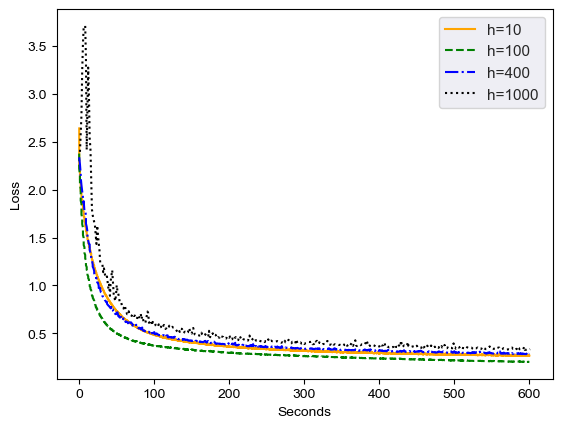

In [14]:
batch = 128
lr = 0.1
time_in_seconds = 60 *10
configuration(n_hidden_nodes=10,batch_size=batch,lr=lr,
              time_in_seconds=time_in_seconds,label="h=10",
              color='orange',linestyle='-')
configuration(n_hidden_nodes=100,batch_size=batch,lr=lr,
              time_in_seconds=time_in_seconds,label="h=100",
              color='green',linestyle='--')
configuration(n_hidden_nodes=400,batch_size=batch,lr=lr,
              time_in_seconds=time_in_seconds,label="h=400",
              color='blue',linestyle='-.')
configuration(n_hidden_nodes=1000,batch_size=batch,lr=lr,
              time_in_seconds=time_in_seconds,label="h=1000",
              color='black',linestyle=':')
show_results()

### Tuning the Learning Rate

Training:  lr=0.001
 Loss: 1.46690898 (4 epochs completed, 2247 total steps)
Training:  lr=0.01
 Loss: 0.45050615 (4 epochs completed, 2306 total steps)
Training:  lr=0.1
 Loss: 0.19139427 (5 epochs completed, 2379 total steps)
Training:  lr=1
 Loss: 0.04948531 (5 epochs completed, 2457 total steps)


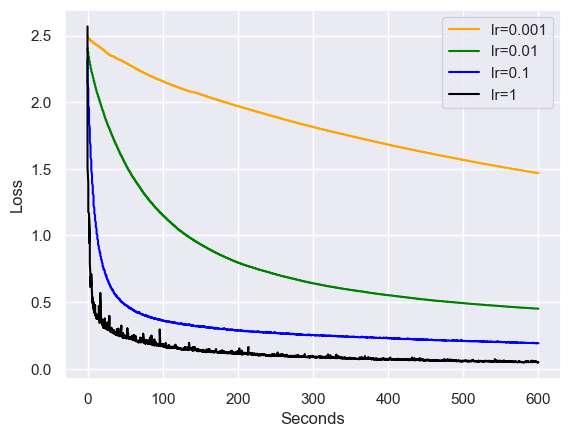

In [15]:
hidden = 100
batch = 128
time_in_seconds = 60 * 10

configuration(n_hidden_nodes=hidden,batch_size=batch,lr=0.001,
              time_in_seconds=time_in_seconds,label="lr=0.001",
              color='orange',linestyle='-')
configuration(n_hidden_nodes=hidden,batch_size=batch,lr=0.01,
              time_in_seconds=time_in_seconds,label="lr=0.01",
              color='green',linestyle='-')
configuration(n_hidden_nodes=hidden,batch_size=batch,lr=0.1,
              time_in_seconds=time_in_seconds,label="lr=0.1",
              color='blue',linestyle='-')
configuration(n_hidden_nodes=hidden,batch_size=batch,lr=1,
              time_in_seconds=time_in_seconds,label="lr=1",
              color='black',linestyle='-')

show_results()

### Tuning the Batch Size

Training:  batch_size=60000
 Loss: 0.08739214 (861 epochs completed, 861 total steps)
Training:  batch_size=256
 Loss: 0.03928927 (10 epochs completed, 2532 total steps)
Training:  batch_size=128
 Loss: 0.04634085 (5 epochs completed, 2551 total steps)
Training:  batch_size=64
 Loss: 0.07008209 (2 epochs completed, 2544 total steps)


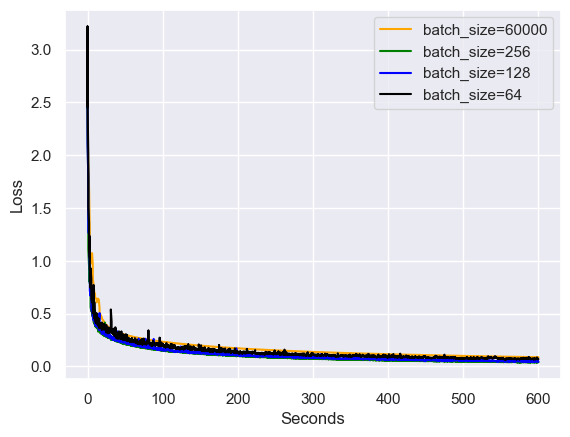

In [16]:
hidden = 100
lr = 1
time_in_seconds = 60 * 10

configuration(n_hidden_nodes=hidden,batch_size=60000,lr=lr,
              time_in_seconds=time_in_seconds,label="batch_size=60000",
              color='orange',linestyle='-')
configuration(n_hidden_nodes=hidden,batch_size=256,lr=lr,
              time_in_seconds=time_in_seconds,label="batch_size=256",
              color='green',linestyle='-')
configuration(n_hidden_nodes=hidden,batch_size=128,lr=lr,
              time_in_seconds=time_in_seconds,label="batch_size=128",
              color='blue',linestyle='-')
configuration(n_hidden_nodes=hidden,batch_size=64,lr=lr,
              time_in_seconds=time_in_seconds,label="batch_size=64",
              color='black',linestyle='-')
show_results()

### The Final Test

In [17]:
def train(X_train,Y_train,X_test,Y_test,n_hidden_nodes,epochs,batch_size,lr):
    n_input_variables = X_train.shape[1]
    n_classes = Y_train.shape[1]

    w1,w2 = initialize_weights(n_input_variables,n_hidden_nodes,n_classes)
    x_batches,y_batches = prepare_batches(X_train,Y_train,batch_size)

    for epoch in range(epochs):
        for batch in range(len(x_batches)):
            y_hat,h = forward(x_batches[batch],w1,w2)
            w1_gradient, w2_gradient = back(x_batches[batch],y_batches[batch],
                                            y_hat,w2,h)
            
            w1 = w1 - (w1_gradient * lr)
            w2 = w2 - (w2_gradient * lr)
            report(epoch,batch,X_train,Y_train,X_test,Y_test,w1,w2)
    return (w1,w2)


In [18]:
train(X_train,Y_train,X_test,Y_test,
      n_hidden_nodes=100,epochs=10,batch_size=256,lr=1)

print("Done.")

    0-0 > Loss: 2.47882835, Accuracy: 43.28%
    0-1 > Loss: 2.32694467, Accuracy: 20.60%
    0-2 > Loss: 1.85616999, Accuracy: 47.08%
    0-3 > Loss: 1.52265514, Accuracy: 62.90%
    0-4 > Loss: 1.26533828, Accuracy: 72.24%
    0-5 > Loss: 1.15565601, Accuracy: 74.36%
    0-6 > Loss: 1.11810973, Accuracy: 71.94%
    0-7 > Loss: 1.03230764, Accuracy: 72.98%
    0-8 > Loss: 1.04851480, Accuracy: 71.52%
    0-9 > Loss: 0.87587435, Accuracy: 78.18%
    0-10 > Loss: 0.75714483, Accuracy: 87.28%
    0-11 > Loss: 0.71626826, Accuracy: 85.44%
    0-12 > Loss: 0.80276474, Accuracy: 78.90%
    0-13 > Loss: 0.85878258, Accuracy: 76.18%
    0-14 > Loss: 0.82602708, Accuracy: 76.68%
    0-15 > Loss: 0.61788923, Accuracy: 88.74%
    0-16 > Loss: 0.57935644, Accuracy: 89.32%
    0-17 > Loss: 0.55528465, Accuracy: 89.82%
    0-18 > Loss: 0.54532592, Accuracy: 89.96%
    0-19 > Loss: 0.53175899, Accuracy: 89.70%
    0-20 > Loss: 0.54089687, Accuracy: 88.80%
    0-21 > Loss: 0.51100295, Accuracy: 90.18